# Illustration of the Large-deviation Theory on the simple example of a sum of Gaussian random variables

In [1]:
using MonteCarloX
using Random
using Plots
using Distributions
using StatsBase
using LinearAlgebra

## Parameters

In [2]:
μ=0
σ=1
N=100;
mean_sum = N*μ
std_sum = sqrt(N)*σ
bins_sum = mean_sum - 5*std_sum : std_sum/20 : mean_sum + 5*std_sum;
centers_sum = (bins_sum[1:end-1] + bins_sum[2:end])/2.0
# expected distribution of the sum of N Gaussian RVs is also Gaussian with mean N*μ and std sqrt(N)*σ
pdf_sum = Normal(N*μ, sqrt(N)*σ)
logpdf_sum = logpdf.(pdf_sum, centers_sum);


## Simple sampling case

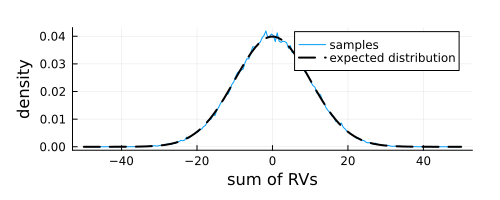

In [3]:
# do simple sampling to get a reference distribution
samples = [sum(μ .+ σ.*randn(MersenneTwister(i), N)) for i in 1:100_000]
# plot histogram as density and compare to expected distribution
hist = fit(Histogram, samples, bins_sum)
# normalize histogram to get density
hist = normalize(hist)
# plot(hist, label="samples", xlabel="sum of RVs", ylabel="density", size=(600,300))
centers= hist.edges[1][1:end-1] .+ diff(hist.edges[1])/2
plot(centers, hist.weights, label="samples", xlabel="sum of RVs", ylabel="density", size=(500,200), margin=5Plots.mm)
x = range(mean_sum - 5*std_sum, mean_sum + 5*std_sum, length=100)
plot!(x, pdf.(pdf_sum, x), label="expected distribution", linestyle=:dash, color=:black, lw=2)

## Importance sampling case

In [4]:
# define the system as a vector of random variables
mutable struct SumGaussianRVs
    logpdf::Function
    rvs::Vector{Float64}
    sum_rvs::Float64
    function SumGaussianRVs(rng, N; μ=0.0, σ=1.0)
        dist = Normal(μ,σ)
        _logpdf = x -> logpdf(dist, x)
        rvs = μ .+ σ.*randn(rng, N)
        sum_rvs = sum(rvs)
        new(_logpdf, rvs, sum_rvs)
    end
end

@inline sum_rvs(sys::SumGaussianRVs) = sys.sum_rvs

# update function 
function update!(sys::SumGaussianRVs, alg::AbstractImportanceSampling; delta::Float64=0.5)
    # randomly select an index to update
    idx = rand(alg.rng, 1:length(sys.rvs))
    rv_old = sys.rvs[idx]
    delta =  delta * ( 2*rand(alg.rng) - 1 ) # uniform in [-delta, delta]
    rv_new = rv_old + delta
    # first accept the proposal using the logpdf difference (future: couple this in new Metropolis-Hastings algorithm)
    if rand(alg.rng) < exp(sys.logpdf(rv_new) - sys.logpdf(rv_old))
        # now check the update according to the algorithm based on the sum_rvs
        sum_new = sys.sum_rvs + delta
        if accept!(alg, sum_new, sys.sum_rvs)
            # modify
            sys.sum_rvs = sum_new
            sys.rvs[idx] = rv_new
        end
    else
        # proposal rejected, do nothing but increase counter for acceptance rate
        alg.steps += 1
    end
end


update! (generic function with 1 method)

In [5]:
sys = SumGaussianRVs(MersenneTwister(42), N, μ=μ, σ=σ)
print("initial sum of RVs = ", sys.sum_rvs, "\n")
alg = Metropolis(MersenneTwister(123), β=0.0)
hist_metropolis = Measurements([
    :sum => sum_rvs => fit(Histogram, [], bins_sum),
], interval=1)

for i in 1:10_000
    update!(sys, alg, delta=0.5)
end

for i in 1:10_000_000
    update!(sys, alg, delta=0.5)
    measure!(hist_metropolis, sys, i)
end
println("acceptance rate = ", acceptance_rate(alg))

initial sum of RVs = 12.945498619237794
acceptance rate = 0.9008678321678322


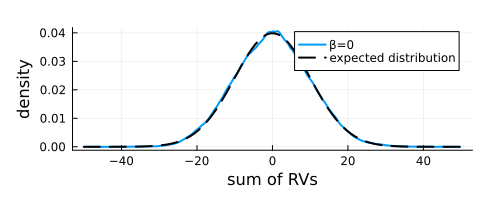

In [6]:
# Compare the measured histogram (from cell above) to the expected Gaussian distribution
norm = sum(hist_metropolis[:sum].data.weights) * (bins_sum[2] - bins_sum[1])
centers = hist_metropolis[:sum].data.edges[1][1:end-1] .+ diff(hist_metropolis[:sum].data.edges[1])/2
p2 = plot(centers, hist_metropolis[:sum].data.weights/norm, label="β=0", lw=2)
x = range(mean_sum - 5*std_sum, mean_sum + 5*std_sum, length=100)
plot!(p2, x, pdf.(pdf_sum, x), label="expected distribution", linestyle=:dash, color=:black, lw=2, size=(500,200), xlabel="sum of RVs", ylabel="density", margin=5Plots.mm)
# plot(p1, p2, layout = @layout([a{0.7w} b]), size=(900,300), margin=5Plots.mm)

## Metropolis

In [42]:
function metropolis_run(; β=0.0)
    print("Running Metropolis with β = ", β, " ... ")
    sys = SumGaussianRVs(MersenneTwister(23), N, μ=μ, σ=σ)
    alg = Metropolis(MersenneTwister(42), β=β)

    hist = Measurements([
        :sum => sum_rvs => fit(Histogram, [], bins_sum),
    ], interval=1)


    for i in 1:10_000
        update!(sys, alg, delta=0.5)
    end

    for i in 1:10_000_000
        update!(sys, alg, delta=0.5)
        measure!(hist, sys, i)
    end
    println("acceptance rate = ", acceptance_rate(alg))
    return hist, sys
end
βs = [-0.1, 0.0, 0.1]
results = Dict(β => metropolis_run(β=β) for β in βs)

Running Metropolis with β = -0.1 ... acceptance rate = 0.8894367632367632
Running Metropolis with β = 0.0 ... acceptance rate = 0.9006661338661338
Running Metropolis with β = 0.1 ... acceptance rate = 0.8898081918081918


Dict{Float64, Tuple{Measurements{Symbol, IntervalSchedule}, SumGaussianRVs}} with 3 entries:
  0.0  => (Measurements{Symbol, IntervalSchedule}(Dict{Symbol, Measurement}(:su…
  -0.1 => (Measurements{Symbol, IntervalSchedule}(Dict{Symbol, Measurement}(:su…
  0.1  => (Measurements{Symbol, IntervalSchedule}(Dict{Symbol, Measurement}(:su…

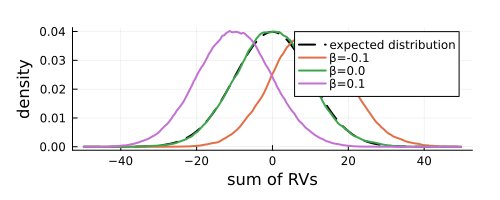

In [52]:
p2 = plot(centers_sum, pdf.(pdf_sum, centers_sum), label="expected distribution", linestyle=:dash, color=:black, lw=2, xlabel="sum of RVs", ylabel="density")

for β in βs
    norm = sum(results[β][1][:sum].data.weights) * (bins_sum[2] - bins_sum[1])
    plot!(p2, centers_sum, results[β][1][:sum].data.weights/norm, label="β=$β", lw=2)
end

plot(p2, size=(500,200), margin=5Plots.mm)

## Multicanonical sampling (equivalent to beta=0)

In [7]:
sys = SumGaussianRVs(MersenneTwister(23), N, μ=μ, σ=σ)
print("initial sum = ", sys.sum_rvs, "\n")
alg = Multicanonical(MersenneTwister(100), BinnedLogWeight(bins_sum, 0.0));

initial sum = -1.4164085925430017


In [8]:
hist_muca_0 = Measurements([
    :sum => sum_rvs => fit(Histogram, [], bins_sum),
], interval=1)

for i in 1:10_000
    update!(sys, alg, delta=0.5)
end

for i in 1:10_000_000
    update!(sys, alg, delta=0.5)
    measure!(hist_muca_0, sys, i)
end
println("acceptance rate = ", acceptance_rate(alg))

acceptance rate = 0.9005543456543457


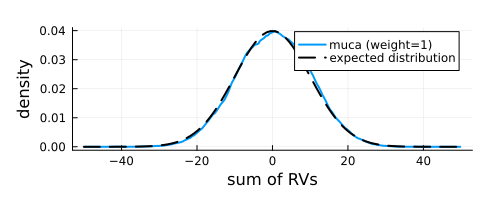

In [9]:
# Compare the measured histogram (from cell above) to the expected Gaussian distribution
norm = sum(hist_muca_0[:sum].data.weights) * (bins_sum[2] - bins_sum[1])
centers = hist_muca_0[:sum].data.edges[1][1:end-1] .+ diff(hist_muca_0[:sum].data.edges[1])/2
p2 = plot(centers, hist_muca_0[:sum].data.weights/norm, label="muca (weight=1)", lw=2)
x = range(mean_sum - 5*std_sum, mean_sum + 5*std_sum, length=100)
plot!(p2, x, pdf.(pdf_sum, x), label="expected distribution", linestyle=:dash, color=:black, lw=2, size=(500,200), xlabel="sum of RVs", ylabel="density", margin=5Plots.mm)

## Multicanonical using the known distribution

initial sum = 12.945498619237794


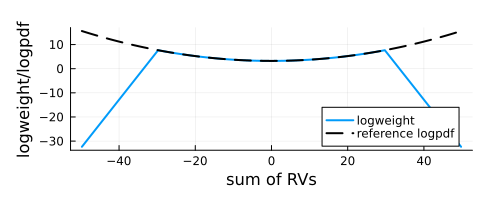

In [13]:
sys = SumGaussianRVs(MersenneTwister(42), N, μ=μ, σ=σ)
print("initial sum = ", sys.sum_rvs, "\n")
alg = Multicanonical(MersenneTwister(42), BinnedLogWeight(bins_sum, 0.0))

alg.logweight.weights .= -logpdf_sum
# avoid runaway
bound_left = first(bins_sum) + 2*σ*sqrt(N)
bound_right = last(bins_sum) - 2*σ*sqrt(N)
idx_bound_left = searchsortedfirst(alg.histogram.bins[1].centers, bound_left) 
idx_bound_right = searchsortedlast(alg.histogram.bins[1].centers, bound_right)
weight_bound_left = alg.logweight.weights[idx_bound_left]
weight_bound_right = alg.logweight.weights[idx_bound_right]
for i in 1:idx_bound_left
    dx = (alg.histogram.bins[1].centers[i] - alg.histogram.bins[1].centers[idx_bound_left])
    alg.logweight.weights[i] = weight_bound_left + dx * 2.0
end
for i in idx_bound_right+1:size(alg.logweight.weights)[1]
    dx = (alg.histogram.bins[1].centers[i] - alg.histogram.bins[1].centers[idx_bound_right])
    alg.logweight.weights[i] = weight_bound_right - dx * 2.0
end

# plot the logweight and compare to the reference logpdf
plot(alg.histogram.bins[1].centers, alg.logweight.weights, label="logweight", lw=2)
plot!(alg.histogram.bins[1].centers, -logpdf_sum, label="reference logpdf", linestyle=:dash, color=:black, lw=2, size=(500,200), xlabel="sum of RVs", ylabel="logweight/logpdf", margin=5Plots.mm)

In [14]:
hist_muca = Measurements([
    :sum => sum_rvs => fit(Histogram, [], bins_sum),
], interval=1)

for i in 1:10_000
    update!(sys, alg, delta=0.1)
end

for i in 1:10_000_000
    update!(sys, alg, delta=0.1)
    measure!(hist_muca, sys, i)
end
println("acceptance rate = ", acceptance_rate(alg))

acceptance rate = 0.9756675324675325


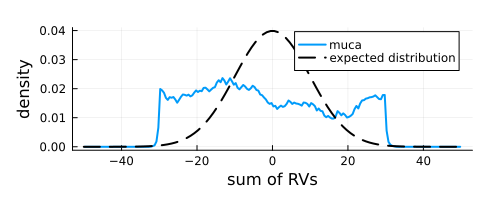

In [15]:
# Compare the measured histogram (from cell above) to the expected Gaussian distribution
norm = sum(hist_muca[:sum].data.weights) * (bins_sum[2] - bins_sum[1])
centers = hist_muca[:sum].data.edges[1][1:end-1] .+ diff(hist_muca[:sum].data.edges[1])/2
p2 = plot(centers, hist_muca[:sum].data.weights/norm, label="muca", lw=2)
x = range(mean_sum - 5*std_sum, mean_sum + 5*std_sum, length=100)
plot!(p2, x, pdf.(pdf_sum, x), label="expected distribution", linestyle=:dash, color=:black, lw=2, size=(500,200), xlabel="sum of RVs", ylabel="density", margin=5Plots.mm)

## Multicanonical iteration

In [19]:
sys = SumGaussianRVs(MersenneTwister(42), N, μ=μ, σ=σ)
print("initial sum = ", sys.sum_rvs, "\n")
alg = Multicanonical(MersenneTwister(42), BinnedLogWeight(bins_sum, 0.0))

# num_iterations
num_iter = 20
histograms = BinnedLogWeight[]
logweights = BinnedLogWeight[]
acceptrate = Float64[]
using ProgressMeter

bound_left = first(bins_sum) + std_sum
bound_right = last(bins_sum) - std_sum
idx_bound_left = searchsortedfirst(alg.histogram.bins[1].centers, bound_left) 
idx_bound_right = searchsortedlast(alg.histogram.bins[1].centers, bound_right)

@showprogress 1 "Running iterations..." for i in 1:num_iter    
    # thermalize the system
    for i in 1:10_000
        update!(sys, alg)
    end
    # reset and start sampling
    reset!(alg)
    for i in 1:10_000_000
        update!(sys, alg)
    end
    
    # # update the logweight
    update_weight!(alg; mode=:simple)   

    # make sure that weights decrease to the ends so that system does not run away
    weight_bound_left = alg.logweight.weights[idx_bound_left]
    weight_bound_right = alg.logweight.weights[idx_bound_right]
    for i in 1:idx_bound_left
        dx = (alg.histogram.bins[1].centers[i] - alg.histogram.bins[1].centers[idx_bound_left])
        alg.logweight.weights[i] = weight_bound_left + dx * 2.0
    end
    for i in idx_bound_right+1:size(alg.logweight.weights)[1]
        dx = (alg.histogram.bins[1].centers[i] - alg.histogram.bins[1].centers[idx_bound_right])
        alg.logweight.weights[i] = weight_bound_right - dx * 2.0
    end

    # record the histogram and weights
    push!(histograms, deepcopy(alg.histogram))
    push!(logweights, deepcopy(alg.logweight))
    push!(acceptrate, acceptance_rate(alg))
end

initial sum = 12.945498619237794


Running iterations... 100%|██████████████████████████████| Time: 0:06:33


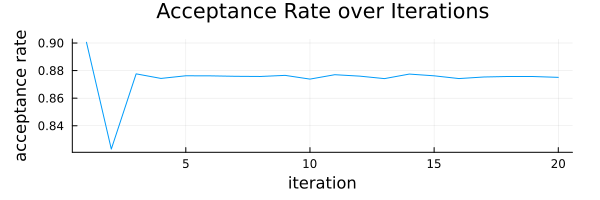

In [20]:
# plot acceptance rate
plot(acceptrate, xlabel="iteration", ylabel="acceptance rate", title="Acceptance Rate over Iterations", label=nothing, size=(600,200), margin=5Plots.mm)

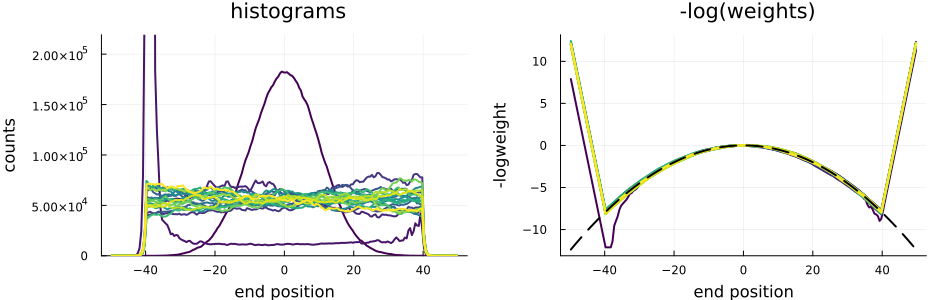

In [ ]:
function plot_histograms_and_logweights(xlabel, hist_vec::Vector{BinnedLogWeight}, lw_vec::Vector{BinnedLogWeight}; title_prefix="", logweight_ylims = :auto)
    n = length(hist_vec)
    cols = palette(:viridis, max(n, 2))[1:n]
    xs = collect(hist_vec[1].bins[1])

    # Plot histograms
    p1 = plot(xs, hist_vec[1].weights; lw=2, color=cols[1], xlabel=xlabel, ylabel="counts", title="$(title_prefix) histograms", legend=false, ylims=(0, maximum(hist_vec[1].weights)*1.2))
    for i in 2:n
        plot!(p1, xs, hist_vec[i].weights; lw=2, color=cols[i])
    end

    # Plot logweights (constrain the upper limit of the logweights to be 0 at the reference point, which is 0 in this case)
    p2 = plot(xlabel=xlabel, ylabel="-logweight", title="$(title_prefix) -log(weights)", legend=false, ylims=logweight_ylims)
    i0 = searchsortedlast(xs, 0.0)
    for i in 1:n
        plot!(p2, xs, -lw_vec[i].weights .+ lw_vec[i].weights[i0]; lw=2, color=cols[i])
    end

    # add reference logpdf as a dashed black line
    plot!(p2, xs, logpdf_sum .- logpdf_sum[i0]; lw=2, color=:black, linestyle=:dash, label="reference logpdf")

    plt = plot(p1, p2, layout=(@layout([a b])), size=(950,300), margin=4Plots.mm)
    return plt
end
plot_histograms_and_logweights("sum of RVs", histograms, logweights)

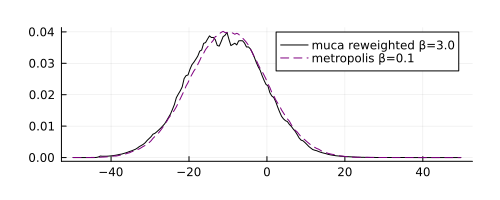

In [ ]:
# reweight the final histogram to get an estimate for β=3 and compare to the metropolis and explicit-weight version

#P(x) = P_muca(x) * exp(-β * x) / W(x) where W(x) is the multicanonical weight, which in this case is exp(-logweight)
hist_reweighted = deepcopy(alg.histogram)
for i in 1:length(hist_reweighted.weights)
    logweight = logweights[end].weights[i]
    hist_reweighted.weights[i] *= exp(-0.1 * hist_reweighted.bins[1].centers[i] - logweight)
end
# hist_reweighted.weights .= exp.(-alg.logweight.weights - 3.0 * hist_reweighted.bins[1].centers)
norm_reweighted = sum(hist_reweighted.weights) * (bins_sum[2] - bins_sum[1])
p = plot(hist_reweighted.bins[1].centers, hist_reweighted.weights / norm_reweighted, label="muca reweighted β=3.0", linestyle=:solid, color=:black)   
# # metropolis
norm = sum(results[0.1][:1][:sum].data.weights) * (bins_sum[2] - bins_sum[1])
plot!(p, centers_sum, results[0.1][:1][:sum].data.weights / norm, label="metropolis β=0.1", linestyle=:dash, color=:purple, size=(500,200), margin=5Plots.mm, xlabel="sum of RVs", ylabel="dist")